In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sbrc_experiment_official.csv")

In [3]:
df.head(3)

,ts_start,ts_end,rep,port,baud,timeout_s,size_bits,margin_samples,total_time_s,throughput_bps,exit_code,stdout_chars,stderr_chars,error_code
0,2026-01-22T19:11:53.596560+00:00,2026-01-22T19:11:54.096493+00:00,1,/dev/ttyACM0,115200,2.0,256,8,0.499911,512.090808,0,64,0,OK
1,2026-01-22T19:11:54.096872+00:00,2026-01-22T19:11:54.601051+00:00,2,/dev/ttyACM0,115200,2.0,256,8,0.504158,507.777179,0,64,0,OK
2,2026-01-22T19:11:54.601256+00:00,2026-01-22T19:11:55.107436+00:00,3,/dev/ttyACM0,115200,2.0,256,8,0.506167,505.761647,0,64,0,OK


In [4]:
def bootstrap_ci(x, stat=np.mean, n_boot=5000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True)
    stats = np.apply_along_axis(stat, 1, boots)
    lo = np.quantile(stats, alpha/2)
    hi = np.quantile(stats, 1 - alpha/2)
    return lo, hi


def plot_time_vs_size_with_ci(df: pd.DataFrame, outpath: str):
    ok = df[df["error_code"] == "OK"].copy()
    groups = ok.groupby("size_bits")

    xs, ys, yerr_lo, yerr_hi = [], [], [], []
    for size, g in groups:
        t = g["total_time_s"].to_numpy()
        mean = t.mean()
        lo, hi = bootstrap_ci(t, np.mean)
        xs.append(size)
        ys.append(mean)
        yerr_lo.append(mean - lo)
        yerr_hi.append(hi - mean)

    # ordena explicitamente
    xs = np.array(xs)
    order = np.argsort(xs)
    xs = xs[order]
    ys = np.array(ys)[order]
    yerr = np.vstack([
        np.array(yerr_lo)[order],
        np.array(yerr_hi)[order],
    ])

    plt.figure()
    plt.errorbar(xs, ys, yerr=yerr, fmt="o-", capsize=5)
    plt.xlabel("size_bits")
    plt.ylabel("tempo médio (s) com IC 95%")
    plt.title("Tempo de coleta vs tamanho gerado (IC 95%)")

    plt.xticks(xs, [str(int(x)) for x in xs])

    plt.grid(True)
    # plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

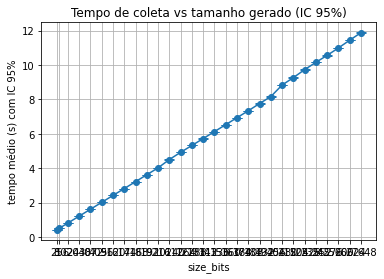

In [5]:
plot_time_vs_size_with_ci(df,'plot')

In [6]:
def plot_boxplot_time_by_size(df: pd.DataFrame, outpath: str):
    ok = df[df["error_code"] == "OK"].copy()
    ok = ok.sort_values("size_bits")

    sizes = sorted(ok["size_bits"].unique())
    data = [ok.loc[ok["size_bits"] == s, "total_time_s"].to_numpy() for s in sizes]

    plt.figure()
    plt.boxplot(data, labels=[str(s) for s in sizes], showfliers=True)
    plt.xlabel("size_bits")
    plt.ylabel("total_time_s")
    plt.title("Distribuição do tempo por size_bits")
    plt.grid(True, axis="y")
    # plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


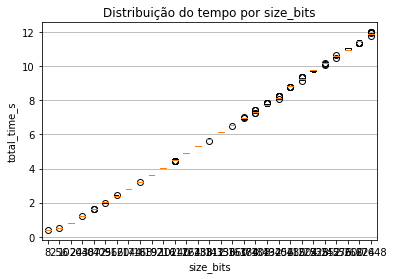

In [7]:
plot_boxplot_time_by_size(df,'plot')

In [8]:
def plot_cost_per_bit(df: pd.DataFrame, outpath: str):
    ok = df[df["error_code"] == "OK"].copy()
    g = ok.groupby("size_bits")

    xs, ys = [], []
    for size, s in g["total_time_s"]:
        xs.append(size)
        ys.append(s.mean() / size)  # s/bit

    order = np.argsort(xs)
    xs = np.array(xs)[order]
    ys = np.array(ys)[order]

    plt.figure()
    plt.plot(xs, ys, marker="o")
    plt.xlabel("size_bits")
    plt.ylabel("tempo por bit (s/bit)")
    plt.title("Custo por bit vs size_bits")

    plt.xticks(xs, [str(int(x)) for x in xs])
    
    plt.grid(True)
    # plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


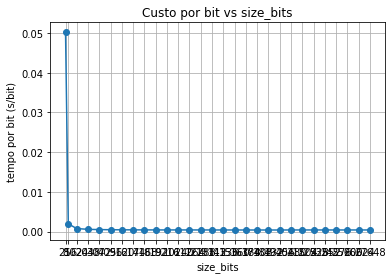

In [9]:
plot_cost_per_bit(df,'plot')

In [10]:
def summarize(df: pd.DataFrame) -> pd.DataFrame:
    # Estatísticas por size_bits (considera apenas OK para latência/throughput)
    ok = df[df["error_code"] == "OK"].copy()

    g = ok.groupby(["size_bits"], dropna=False)

    summary = g.agg(
        n=("total_time_s", "size"),
        time_mean_s=("total_time_s", "mean"),
        time_std_s=("total_time_s", "std"),
        thr_mean_bps=("throughput_bps", "mean"),
        thr_std_bps=("throughput_bps", "std"),
    ).reset_index()

    qdf = g["total_time_s"].quantile([0.50, 0.95, 0.99]).unstack()

    # Renomeia as colunas numéricas para nomes estáveis
    qdf = qdf.rename(columns={
        0.50: "time_p50_s",
        0.95: "time_p95_s",
        0.99: "time_p99_s",
    }).reset_index()

    summary = summary.merge(qdf, on="size_bits", how="left")

    # Taxa de erro por size_bits (considera tudo)
    err = (
        df.assign(is_ok=(df["error_code"] == "OK"))
          .groupby("size_bits")["is_ok"]
          .agg(n_total="size", n_ok="sum")
          .reset_index()
    )
    err["error_rate_pct"] = (1.0 - (err["n_ok"] / err["n_total"])) * 100.0

    summary = summary.merge(err[["size_bits", "n_total", "error_rate_pct"]], on="size_bits", how="left")
    summary = summary.sort_values("size_bits").reset_index(drop=True)
    return summary

In [11]:
summary = summarize(df)
summary

,size_bits,n,time_mean_s,time_std_s,thr_mean_bps,thr_std_bps,time_p50_s,time_p95_s,time_p99_s,n_total,error_rate_pct
0,8,30,0.401406,0.002885,19.930938,0.141802,0.400958,0.404382,0.409786,30,0.0
1,256,30,0.504275,0.004530,507.698464,4.542760,0.504117,0.510902,0.515799,30,0.0
2,1024,30,0.805176,0.004064,1271.802615,6.407011,0.804387,0.812806,0.813517,30,0.0
3,2048,30,1.206416,0.003333,1697.602086,4.694263,1.207029,1.211738,1.212402,30,0.0
4,3072,30,1.607777,0.003129,1910.719540,3.713981,1.607466,1.613516,1.615270,30,0.0
5,4096,30,2.008793,0.002695,2039.038487,2.738063,2.008648,2.012830,2.014184,30,0.0
6,5120,30,2.412901,0.004928,2121.935857,4.330323,2.412313,2.421127,2.424868,30,0.0
7,6144,30,2.811836,0.005772,2185.057803,4.484604,2.811349,2.820123,2.823170,30,0.0
8,7168,30,3.213370,0.004153,2230.683536,2.880568,3.212770,3.219728,3.223510,30,0.0
9,8192,30,3.617367,0.004525,2264.633840,2.833945,3.618655,3.623953,3.624291,30,0.0


In [12]:
def plot_throughput(summary: pd.DataFrame, outdir: str) -> None:
    x = summary["size_bits"].to_numpy()
    y = summary["thr_mean_bps"].to_numpy()

    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel("size_bits")
    plt.ylabel("throughput médio (bits/s)")
    plt.title("Throughput médio vs size_bits")
    plt.xticks(rotation=90)

    plt.xticks(x, [str(int(x)) for x in x])
    plt.grid(True)
    # plt.savefig(f"{outdir}/throughput_mean_vs_size_bits.png",
    #             dpi=200, bbox_inches="tight")
    plt.show()
    # plt.close()

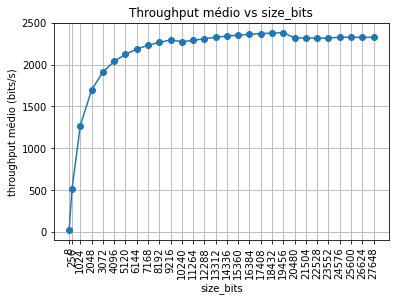

In [13]:
plot_throughput(summary, 'plot')

In [14]:
def plot_latency_quantiles(summary: pd.DataFrame, outdir: str) -> None:
    x = summary["size_bits"].to_numpy()

    quantiles = [
        ("time_p50_s", "p50"),
        ("time_p95_s", "p95"),
        ("time_p99_s", "p99"),
    ]

    for col, label in quantiles:
        y = summary[col].to_numpy()

        plt.figure()
        plt.plot(x, y, marker="o")
        plt.xlabel("size_bits")
        plt.ylabel(f"latência {label} (s)")
        plt.title(f"Latência {label} vs size_bits")
        plt.xticks(x, [str(int(x)) for x in x])
        
        plt.grid(True)
        # plt.savefig(f"{outdir}/latency_{label}_vs_size_bits.png",
        #             dpi=200, bbox_inches="tight")
        # plt.close()
        plt.show()

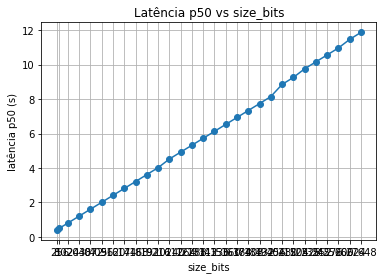

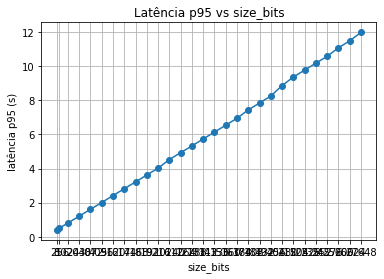

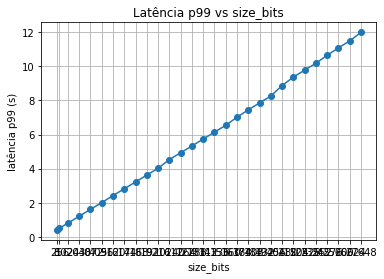

In [15]:
plot_latency_quantiles(summary, 'plot')